In [2]:
!pip install pycuda

In [1]:
import cv2
import numpy as np
import cupy as cp
from cupy.cuda import texture as tex
import matplotlib.pyplot as plt

In [2]:
# Добавление шума "Salt-and-pepper"

def add_salt_pepper(image, prob=0.1):
    noisy = image.copy()
    h, w = noisy.shape
    mask = np.random.random((h, w)) < prob
    salt_pepper = np.random.randint(0, 2, (h, w), dtype=np.uint8) * 255
    noisy[mask] = salt_pepper[mask]
    return noisy

In [3]:
# Медианный фильтр на GPU с текстурной памятью

def median_filter_gpu(image, kernel_size=3):
    """
    image: 2D numpy array (uint8), grayscale
    kernel_size: 3 (фиксировано)
    возвращает отфильтрованное изображение (numpy, uint8) и время GPU в секундах
    """
    h, w = image.shape
    pad = kernel_size // 2

    # Дополняем изображение для обработки краёв
    padded = np.pad(image, pad, mode='edge').astype(np.float32)
    img_gpu = cp.asarray(padded, dtype=cp.float32)

    # Создаём CUDA массив для текстуры
    channel_desc = tex.ChannelFormatDescriptor(
        32, 0, 0, 0,
        cp.cuda.runtime.cudaChannelFormatKindFloat
    )
    cu_arr = tex.CUDAarray(channel_desc, w + 2*pad, h + 2*pad)
    cu_arr.copy_from(img_gpu)

    # Ресурсный дескриптор
    res_desc = tex.ResourceDescriptor(
        cp.cuda.runtime.cudaResourceTypeArray,
        cu_arr
    )
    # Текстурный дескриптор: clamp, точечная фильтрация (без интерполяции)
    tex_desc = tex.TextureDescriptor(
        addressModes=[cp.cuda.runtime.cudaAddressModeClamp] * 2,
        filterMode=cp.cuda.runtime.cudaFilterModePoint,
        readMode=cp.cuda.runtime.cudaReadModeElementType,
        normalizedCoords=False
    )
    tex_obj = tex.TextureObject(res_desc, tex_desc)

    # CUDA ядро для медианного фильтра 3x3
    kernel_code = r'''
    __device__ void sort9(unsigned char *a) {
        // Пузырьковая сортировка для 9 элементов
        for (int i = 0; i < 8; ++i) {
            for (int j = 0; j < 8 - i; ++j) {
                if (a[j] > a[j+1]) {
                    unsigned char tmp = a[j];
                    a[j] = a[j+1];
                    a[j+1] = tmp;
                }
            }
        }
    }

    extern "C" __global__ void medianFilter3x3(cudaTextureObject_t texInput,
                                               unsigned char* img_output,
                                               int width, int height,
                                               int pad)
    {
        int x = blockIdx.x * blockDim.x + threadIdx.x;
        int y = blockIdx.y * blockDim.y + threadIdx.y;
        if (x >= width || y >= height) return;

        int xp = x + pad;
        int yp = y + pad;

        unsigned char window[9];
        int idx = 0;
        for (int dy = -pad; dy <= pad; ++dy) {
            for (int dx = -pad; dx <= pad; ++dx) {
                // Смещение 0.5f для корректного чтения пикселей
                float val = tex2D<float>(texInput, xp + dx + 0.5f, yp + dy + 0.5f);
                window[idx++] = (unsigned char)val;
            }
        }

        sort9(window);
        img_output[y * width + x] = window[4];  // медиана
    }
    '''

    mod = cp.RawModule(code=kernel_code, backend='nvrtc')
    kernel = mod.get_function('medianFilter3x3')

    output_gpu = cp.zeros((h, w), dtype=cp.uint8)

    block = (16, 16, 1)
    grid = (int(np.ceil(w / 16)), int(np.ceil(h / 16)), 1)

    start = cp.cuda.Event()
    end = cp.cuda.Event()
    start.record()

    kernel(
        grid, block, (
            tex_obj,
            output_gpu.data.ptr,
            np.int32(w), np.int32(h),
            np.int32(pad)
        )
    )
    end.record()
    end.synchronize()
    gpu_time_ms = cp.cuda.get_elapsed_time(start, end)
    gpu_time_s = gpu_time_ms / 1000.0

    result = cp.asnumpy(output_gpu)
    return result, gpu_time_s


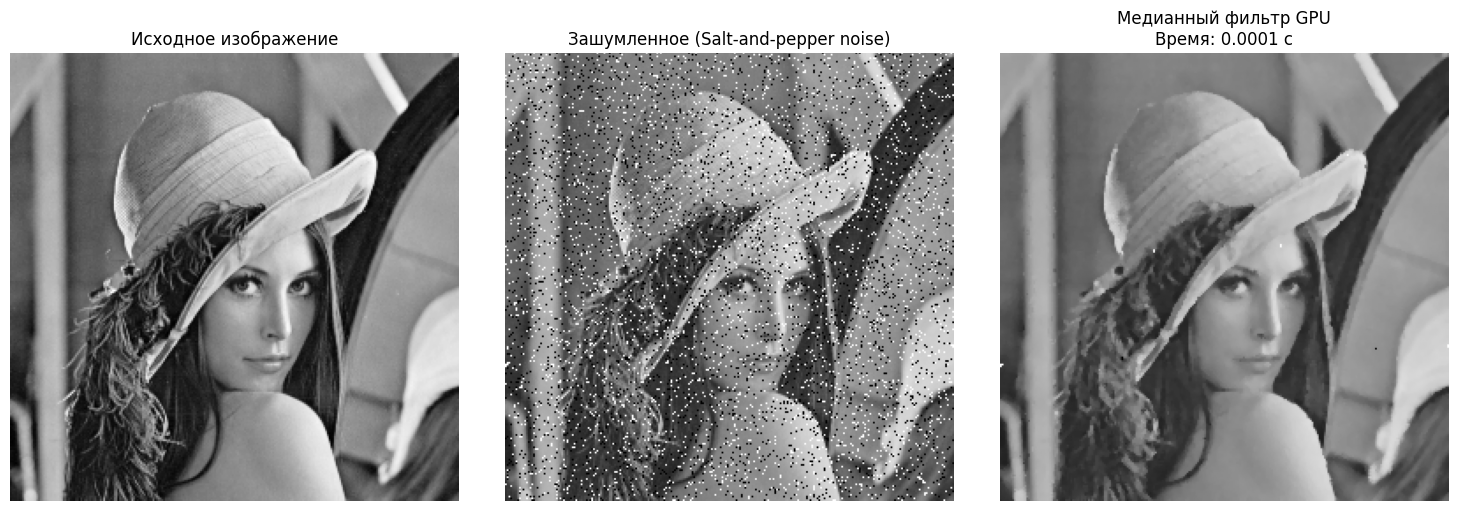

Время обработки GPU: 0.000114 секунд
Результаты сохранены: noisy_image.bmp, filtered_image.bmp


In [4]:
# Основная программа
if __name__ == "__main__":

    image_path = "Lena.bmp"
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print("Ошибка: не удалось загрузить изображение. Проверьте путь.")
        exit()

    img = cv2.resize(img, (255, 255))
    noisy = add_salt_pepper(img, prob=0.1)
    filtered, gpu_time = median_filter_gpu(noisy, kernel_size=3)

    # Визуализация
    plt.figure(figsize=(15, 5))
    plt.subplot(1, 3, 1)
    plt.imshow(img, cmap='gray')
    plt.title('Исходное изображение')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(noisy, cmap='gray')
    plt.title('Зашумленное (Salt-and-pepper noise)')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(filtered, cmap='gray')
    plt.title(f'Медианный фильтр GPU\nВремя: {gpu_time:.4f} с')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    # Сохранение результатов
    cv2.imwrite('noisy_image.bmp', noisy)
    cv2.imwrite('filtered_image.bmp', filtered)

    print(f"Время обработки GPU: {gpu_time:.6f} секунд")
    print("Результаты сохранены: noisy_image.bmp, filtered_image.bmp")